<a href="https://colab.research.google.com/github/susu-xxx/MyStudy/blob/DeepLearning/ex02)_%EC%86%90%EA%B8%80%EC%94%A8_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EB%A5%98(%EB%8B%A4%EC%A4%91%EB%B6%84%EB%A5%98)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


In [ ]:
!pwd

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


In [ ]:
# 기본 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 데이터 로딩

In [ ]:
# keras 내부에서 제공해주는 손글씨 데이터 불러오기
from tensorflow.keras.datasets import mnist

In [ ]:
(a,b), (c,d) = ([1,2],[3,4]),([5,6],[7,8])

In [ ]:
# 훈련용 데이터 , 테스트 데이터 모두 나뉘어저ㅕ 있음. 한 번에 다운해서  저장
(x_train, y_train),(x_test,y_test) = mnist.load_data()

In [ ]:
# data 크기 확인
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

#학습용 데이터는 6만장, 테스트 데이터는 1만장
# 28*28 픽셀

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
#정답 데이터 확인
np.unique(y_train)

# 0-9 손글씨 데이터
# 클래스 10개 -> 다중분류
# 0-9까지의 숫자 중 하나를 예측하는 모델 리을 진행

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

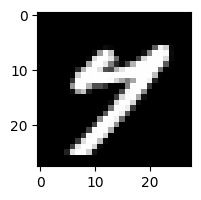

In [ ]:
# 사진 데이터 확인
plt.figure(figsize=(2,2))
plt.imshow(x_train[1001], cmap= 'gray') #1002번째 데이터

In [ ]:
x_train[1001] #라벨링된 데이터가 정답 데이터에 들어있음

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,  13,
          7,   0,   0,   0,   0,   0,   0,   2,  93, 244, 207,   8,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  15, 157, 254,
        197,   0,   0,   0,   0,   0,  18, 131, 254, 254, 248,  11,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   9, 220, 254, 254,
        230, 104,   0,   0,   0,  65, 216, 254, 254, 254, 218,   8,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 169, 254, 254, 231,
        126,  40,  11,  70, 180, 254, 254, 254, 254, 254,  90,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  40, 183, 251, 254, 226,  81,
         70, 180, 229, 254, 254, 254, 254, 254, 254, 115,   3,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   7, 208, 254, 254, 255, 254, 254,
        254, 255, 254, 254, 254, 254, 254, 254, 190,   3,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  53, 254, 254, 254, 254, 254, 253,
        250, 212, 169, 125, 167, 254, 254, 241,  35,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 150, 254, 254, 181,  77,  77,  48,
          0,   0,   0, 128, 254, 254, 253,  57,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  14, 157, 195,  29,   0,   0,   0,
          0,   0,  75, 248, 254, 254, 139,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  59, 217, 254, 254, 170,  15,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         15, 217, 254, 254, 214,  15,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   5,
        113, 254, 254, 238,  55,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,  89,
        254, 254, 239,  81,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 141, 254,
        254, 240, 106,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  66, 252, 254,
        252, 145,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  68, 250, 254, 252,
        171,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  54, 249, 254, 254, 210,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  56, 223, 254, 254, 189,  11,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  6

In [ ]:
y_train[1001]
#흑백 사진은 (0-255)
#0: 검은색
#255 : 흰색

np.uint8(7)

### MLP 모델링
- 입력층의 구조, 출력층 구조 (다중 분류)
- 학습 능력을 위한 중간층의 깊이 고려
- lose, optimizer 설정
- 학습 결과 시각화를 통한 일반화 판단

In [ ]:
# 필요한 라이브러리 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Flatten

#Flatten : 2차원의 사진데이터를 1차원으로 표현해주기 위한 클래스
#현재 우리의 데이터셋은 2차원 형태 ->1차원 (선형모델을 돌리기 위해)

In [ ]:
# 더 깊게 은닉층을 쌓아보자

# 1 .모델 설계
# 뼈대
model = Sequential()

#입력층
model.add(InputLayer(input_shape=(28,28))) #2차원 데이터

#중간층
model.add(Flatten()) #1차원으로 바꿔주는 클래스 (선형모델 작업을 위해)

#은닉층
model.add(Dense(units=16, activation='sigmoid'))
model.add(Dense(units=8, activation='sigmoid'))

#출력층
model.add(Dense(units=10, activation='softmax')) #unit은 클래스의 개수만큼(0-9)

#다중분류 시 출력층에서 사용하는 활성화 함수 : softmax
#softmax : 각각의 확률값(클래스 개수만큼의)의 총합이 1이 되도록 변황해주는 함수

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
#모델 학습방법 및 평가 설정
model.compile(optimizer='SGD',
              loss='categorical_crossentropy', #다중분류
              metrics=['accuracy'])



In [ ]:
#모델 학습
''' h = model.fit(x_train, y_train,
              validation_split=0.2,#train 데이터 내의 모의고사 정답 데이터
              epochs=20, # 학습 몇 번 반복할 건지
              batch_size=32 #디폴트값, 보통 32나 64로 놓음
              ) '''
#오류 확인 -> 정답 데이터의 shape가 일치하지 않음
#y_train 형태를 확인해보니 1개의 결과값(0-9 클래스 중 화나 )
# 모델링 출력 결과 : 10개의 클래스에 대한 각각의 확률값

# 모델 출력값 10개,
# 정답값 1개

#문제 해결 방법
#방법 11, 정답데이터의 형태를 원-핫 인코딩
#방법 2. compile 단계에서 로스 함수를 sparse_categorical_crossentropy -> 정답 데이터를 자동으로 인코딩하여 계싼

' h = model.fit(x_train, y_train, \n              validation_split=0.2,#train 데이터 내의 모의고사 정답 데이터\n              epochs=20, # 학습 몇 번 반복할 건지\n              batch_size=32 #디폴트값, 보통 32나 64로 놓음\n              ) '

In [ ]:
#1, 정답데이터의 형태를 원-핫 인코딩
#모델의 예측값은 클래스의 개수만큼의 확률값으로 출력되기에 정답 데이터를 원핫인코딩된 형태로 변경

#정수형 라벨을 원핫인코딩된 벡터의 형태로 변환하는 도구
# 각 클래스를 벡터로 표현, 해당 클래스에 해당하는 인덱스 위치에1, 나머지 0
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train)
y_train_onehot[0:2]


array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
y_train[45] # 왜 9가 나오지?

np.uint8(9)

In [ ]:
h = model.fit(x_train, y_train_onehot,
              validation_split=0.2,
              epochs=20,
              batch_size=32
              )
#실행 안되면 모델 설계단계부터 다시 실행

Epoch 1/20


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(32, 10), output.shape=(32, 10)

In [ ]:
#방법 2 compile 에서 loss를 sparse_categorical_crossentropy
model.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

h = model.fit(x_train, y_train,
              validation_split=0.2,
              epochs=20,
              batch_size=32
              )

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2292 - loss: 2.1921 - val_accuracy: 0.5114 - val_loss: 1.8526
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5319 - loss: 1.7796 - val_accuracy: 0.5736 - val_loss: 1.5741
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5870 - loss: 1.5332 - val_accuracy: 0.6369 - val_loss: 1.4065
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6446 - loss: 1.3740 - val_accuracy: 0.7067 - val_loss: 1.2636
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7025 - loss: 1.2484 - val_accuracy: 0.7398 - val_loss: 1.1457
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7236 - loss: 1.1439 - val_accuracy: 0.7444 - val_loss: 1.0721
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7539 - loss: 1.0382 - val_accuracy: 0.7754 - val_loss: 0.9384
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7693 - loss: 0.9452 - 

In [ ]:
# 평가
model.evaluate(x_test, y_test)

# 최종평가 정확도 : 약 84% 정도

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8237 - loss: 0.5893


[0.542765736579895, 0.8418999910354614]

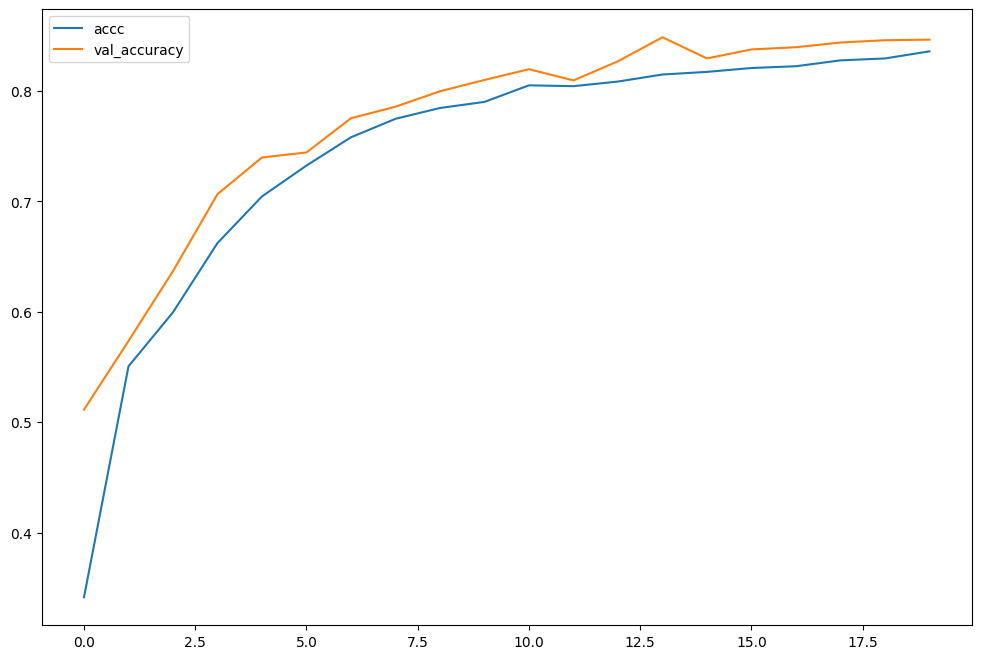

In [ ]:
# 시각화
plt.figure(figsize=(12,8))
plt.plot(h.history['accuracy'], label='accc')
plt.plot(h.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [ ]:
# 더 깊게 은닉층을 쌓아보자

# 1 .모델 설계
# 뼈대
model = Sequential()

#입력층
model.add(InputLayer(input_shape=(28,28))) #2차원 데이터

#중간층
model.add(Flatten()) #1차원으로 바꿔주는 클래스 (선형모델 작업을 위해)

#은닉층
model.add(Dense(units=64, activation='sigmoid'))
model.add(Dense(units=128, activation='sigmoid'))
model.add(Dense(units=256, activation='sigmoid'))
model.add(Dense(units=128, activation='sigmoid'))
model.add(Dense(units=64, activation='sigmoid'))


#출력층
model.add(Dense(units=10, activation='softmax')) #unit은 클래스의 개수만큼(0-9)

# 2. 학습방법 및 평가방법 설정
model.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

h = model.fit(x_train, y_train,
              validation_split=0.2,
              epochs=20,
              batch_size=64
              )
#배치사이즈
# 모델이 한번에 학습하는 데이터 샘플의 개수
# 전체 데이터셋을 한 번에 학습할 경우, 메모리 문제 발생
#데이터셋을 작은 단위로 나누어 모델에 입력, 이 단위를 배치
# 디폴트 32, 주로 32 or 64 사용 , 32가 느리지만 일반화에 조금 더 유리

#평가
model.evaluate(x_test, y_test)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1053 - loss: 2.3232 - val_accuracy: 0.1060 - val_loss: 2.3025
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1113 - loss: 2.3014 - val_accuracy: 0.1060 - val_loss: 2.3016
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1122 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3014
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1152 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3015
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1137 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3010
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1121 - loss: 2.3006 - val_accuracy: 0.1060 - val_loss: 2.3014
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1134 - loss: 2.3001 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1159 - loss: 2.2992 - val_accuracy: 0.

[2.284796953201294, 0.11349999904632568]

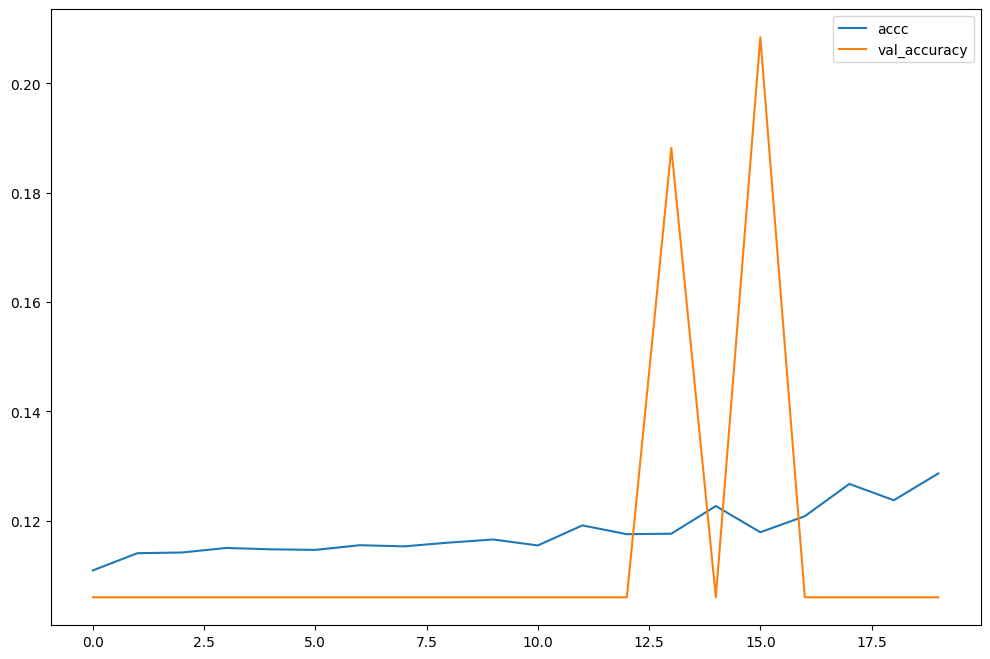

In [ ]:
# 시각화
plt.figure(figsize=(12,8))
plt.plot(h.history['accuracy'], label='accc')
plt.plot(h.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [ ]:
# 성능 꾸짐..

### 활성화 함수, 최적화함수 조합에 따른 성능 비교

- 손글씨 데이터
1. sigmoid, SGD 조합
2. relu + SGD 조합  
3. relu + adam 조합  


In [ ]:
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
# 1. sigmoid, SGD 조합

# 1 .모델 설계
# 뼈대
model1 = Sequential()

#입력층
model1.add(InputLayer(input_shape=(28,28))) #2차원 데이터

#중간층
model1.add(Flatten()) #1차원으로 바꿔주는 클래스 (선형모델 작업을 위해)

#은닉층
model1.add(Dense(units=64, activation='sigmoid'))
model1.add(Dense(units=128, activation='sigmoid'))
model1.add(Dense(units=256, activation='sigmoid'))
model1.add(Dense(units=128, activation='sigmoid'))
model1.add(Dense(units=64, activation='sigmoid'))


#출력층
model1.add(Dense(units=10, activation='softmax')) #unit은 클래스의 개수만큼(0-9)

# 2. 학습방법 및 평가방법 설정
model1.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. 학습
h1 = model1.fit(x_train, y_train,
              validation_split=0.2,
              epochs=20,
              )





Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1140 - loss: 2.3343 - val_accuracy: 0.1060 - val_loss: 2.3039
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1154 - loss: 2.3014 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1135 - loss: 2.3008 - val_accuracy: 0.1060 - val_loss: 2.3002
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1150 - loss: 2.2993 - val_accuracy: 0.1081 - val_loss: 2.2994
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.1176 - loss: 2.2984 - val_accuracy: 0.1060 - val_loss: 2.2977
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.1226 - loss: 2.2965 - val_accuracy: 0.1060 - val_loss: 2.2955
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1265 - loss: 2.2943 - val_accuracy: 0.1060 - val_loss: 2.2942
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1249 - loss: 2.2921 

In [ ]:

# 1. relu, SGD 조합

# 1 .모델 설계
# 뼈대
model2 = Sequential()

#입력층
model2.add(InputLayer(input_shape=(28,28))) #2차원 데이터

#중간층
model2.add(Flatten()) #1차원으로 바꿔주는 클래스 (선형모델 작업을 위해)

#은닉층
model2.add(Dense(units=64, activation='relu'))
model2.add(Dense(units=128, activation='relu'))
model2.add(Dense(units=256, activation='relu'))
model2.add(Dense(units=128, activation='relu'))
model2.add(Dense(units=64, activation='relu'))


#출력층
model2.add(Dense(units=10, activation='softmax')) #unit은 클래스의 개수만큼(0-9)

# 2. 학습방법 및 평가방법 설정
model2.compile(optimizer=SGD(learning_rate = 0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#확률적 경사하강법의 기본 학습률 = 0.01
# 학습률이 큰 경우 오차가 큰 값이 그대로 전달되면서 변동이 크다.
#relu 함수의 경우 오차가 줄어들지 않을 수가 있음.

# 3. 학습
h2 = model2.fit(x_train, y_train,
              validation_split=0.2,
              epochs=20,
              )





Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7129 - loss: 1.6793 - val_accuracy: 0.8907 - val_loss: 0.3623
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9075 - loss: 0.3098 - val_accuracy: 0.9209 - val_loss: 0.2703
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9312 - loss: 0.2255 - val_accuracy: 0.9312 - val_loss: 0.2347
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9415 - loss: 0.1906 - val_accuracy: 0.9372 - val_loss: 0.2179
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9523 - loss: 0.1585 - val_accuracy: 0.9425 - val_loss: 0.2009
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9602 - loss: 0.1316 - val_accuracy: 0.9417 - val_loss: 0.2064
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9637 - loss: 0.1179 - val_accuracy: 0.9463 - val_loss: 0.1999
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9680 - loss: 0.103

In [ ]:

# 1. relu, adam 조합

# 1 .모델 설계
# 뼈대
model3 = Sequential()

#입력층
model3.add(InputLayer(input_shape=(28,28))) #2차원 데이터

#중간층
model3.add(Flatten()) #1차원으로 바꿔주는 클래스 (선형모델 작업을 위해)

#은닉층
model3.add(Dense(units=64, activation='relu'))
model3.add(Dense(units=128, activation='relu'))
model3.add(Dense(units=256, activation='relu'))
model3.add(Dense(units=128, activation='relu'))
model3.add(Dense(units=64, activation='relu'))


#출력층
model3.add(Dense(units=10, activation='softmax')) #unit은 클래스의 개수만큼(0-9)

# 2. 학습방법 및 평가방법 설정
model3.compile(optimizer=Adam(learning_rate = 0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#확률적 경사하강법의 기본 학습률 = 0.01
# 학습률이 큰 경우 오차가 큰 값이 그대로 전달되면서 변동이 크다.
#relu 함수의 경우 오차가 줄어들지 않을 수가 있음.

# 3. 학습
h3 = model3.fit(x_train, y_train,
              validation_split=0.2,
              epochs=20,
              )





Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7654 - loss: 1.4259 - val_accuracy: 0.9293 - val_loss: 0.2379
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9365 - loss: 0.2163 - val_accuracy: 0.9460 - val_loss: 0.1910
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9520 - loss: 0.1662 - val_accuracy: 0.9350 - val_loss: 0.2240
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9580 - loss: 0.1413 - val_accuracy: 0.9525 - val_loss: 0.1844
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9637 - loss: 0.1293 - val_accuracy: 0.9651 - val_loss: 0.1315
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9704 - loss: 0.1014 - val_accuracy: 0.9621 - val_loss: 0.1387
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9739 - loss: 0.0965 - val_accuracy: 0.9676 - val_loss: 0.1247
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9770 - loss: 0.0821 -

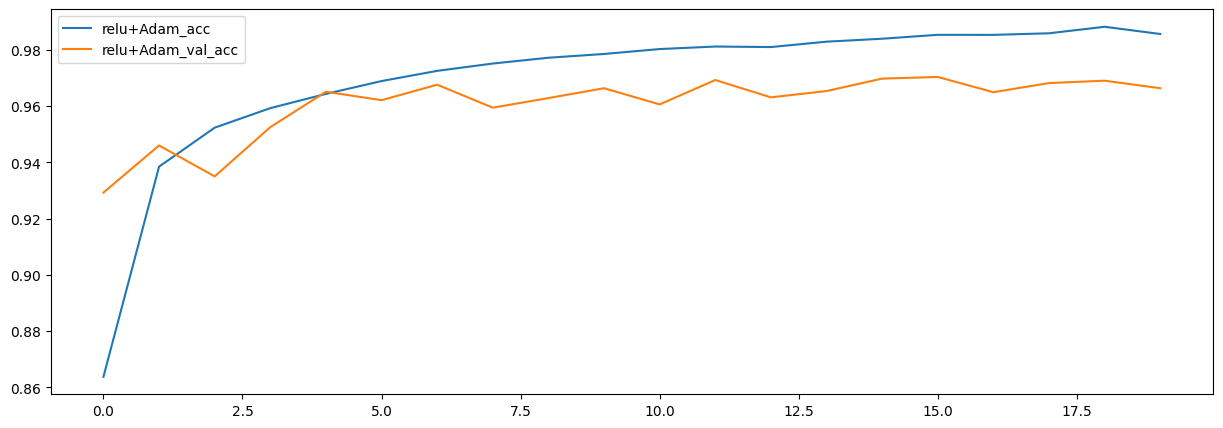

In [ ]:
# h1, h2, h3 시각화

plt.figure(figsize=(15,5))
'''
#1. sig + SGD
plt.plot(h1.history['accuracy'], label='sig+SGD_acc')
plt.plot(h1.history['val_accuracy'], label='sig+SGD_val_acc')

#2. relu + SGD
plt.plot(h2.history['accuracy'], label='relu+SGD_acc')
plt.plot(h2.history['val_accuracy'], label='relu+SGD_val_acc')
'''


#3. relu + Adam
plt.plot(h3.history['accuracy'], label='relu+Adam_acc')
plt.plot(h3.history['val_accuracy'], label='relu+Adam_val_acc')

plt.legend()
plt.show()

#sig + SGD : 비교적 낮은 학습 속도와 정확도
# relu + SGD  : 비교적 빠른 학습 속도와 높은 정확도, Adam에 비해 다소 부족
# relu + Adam : 속도도 가장 빠르고 높은 정확도, Adam의 적응형 학습률효과 덕분에 매우 효과적으로 학습이 진행된 것으로 보인다.


#### callback 함수


모델 저장 및 조기학습 중단
- 모델 저장 : 딥러닝 모델학습 시 지정된 epoch를 다 끝내는 경우  과대적합이 발생할 쇼ㅜ 있음 -> 중간에 일반화면 모델 따로 저장할 수 있는 기능


- 조기학습중단 (early stopping ) epoch를 크게 설정할 경우 일정 횟수 이후로는 모델의 성능이 개선되지 않을 수 있다. = 시간낭비
-> 모델의 성능이 더 이상 개선되지 않는 경우에 조기학습 중단기능


In [ ]:
# 학습된 모델 저장하기
model3.save('./data/hand_moodel.keras')

#모델 저장할 떄 (.h5 , .hdf5) 확장자를 사용해 왔지만
#최근에는 keras 자체의 새로운 파일 형식을 사용하는 것을 권장

In [ ]:
from tensorflow.keras.datasets import mnist
(x_train, y_train),(x_test,y_test) = mnist.load_data()

In [ ]:
from tensorflow.keras.models import load_model
loades_model = load_model('./data/hand_moodel.keras')

In [ ]:
x_test[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  84, 185, 159, 151,  60,  36,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 222, 254, 254, 254, 254, 241, 198,
        198, 198, 198, 198, 198, 198, 198, 170,  52,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  67, 114,  72, 114, 163, 227, 254,
        225, 254, 254, 254, 250, 229, 254, 254, 140,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  17,  66,
         14,  67,  67,  67,  59,  21, 236, 254, 106,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  83, 253, 209,  18,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  22, 233, 255,  83,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 129, 254, 238,  44,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  59, 249, 254,  62,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 133, 254, 187,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   9, 205, 248,  58,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 254, 182,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  75, 251, 240,  57,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         19, 221, 254, 166,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
        203, 254, 219,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38,
        254, 254,  77,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 224,
        254, 115,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 133, 254,
        254,  52,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
# 학습된 모델 불러와서 사용
loades_model.predict(x_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.1370838e-31, 7.6038651e-21, 5.4656409e-17, 3.1768249e-14,
       1.7577596e-17, 1.3213594e-20, 0.0000000e+00, 9.9999994e-01,
       1.5607992e-30, 4.4720134e-19], dtype=float32)

In [ ]:
import numpy as np


In [ ]:
np.round(loades_model.predict(x_test)[0],2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.], dtype=float32)

In [ ]:
loades_model.predict(x_test)[0].argmax()
# .argmax() 가장 큰 값의 인덱스 위치 반환

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


np.int64(7)

In [ ]:
# 학습 중단의 기능 (Early stopping) -> epoch 1000 이어도 중간에 확인해보고 학습 개선이 안 되면 학습 중단
# 중간 모델 저장 기능 (ModelCheckpoint) -> 모든 모델. 좋았던 모델만 저장
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
#모델 저장 폴더 및 저장 파일명 지정
# epoch:03d : 학습의 순서 차구, d는 10진 정수에 대한 자리 표시자
# 03은 정수가 3자리 길이로 구성되어야 한다. 1-> 001

# val_accuracy:.4f: 검증 정확도를 소수점 넷째 자리까지 표현
modelpath = './data/handmodel-{epoch:03d}-{val_accuracy:.4f}.keras'

In [ ]:
# 전보다 나은 정확도를 보이면 저장
modelcheckpoint_callback = ModelCheckpoint(filepath=modelpath, #파일 저장될 경로
                                  monitor='val_accuracy', # 검증 정확도를 기준으로 나아진 걸 판단
                                  verbose=1, #과정 출력
                                  save_best_only=True) #더 나아진 결과만 저장하는 옵션, False= 모든 epoch 저장

In [ ]:
# 전보다 나아지지 않으면 학습 중단
early_stopping_callback = EarlyStopping(monitor='val_accuracy',
                                         patience=5 )# 5회 이상 개선되지 않으면 중단


In [ ]:
#필요한 라이브러리 import
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Flatten
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
#기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

# 1 .모델 설계
# 뼈대
model4 = Sequential()

#입력층
model4.add(InputLayer(input_shape=(28,28))) #2차원 데이터

#중간층
model4.add(Flatten()) #1차원으로 바꿔주는 클래스 (선형모델 작업을 위해)

#은닉층
model4.add(Dense(units=64, activation='relu'))
model4.add(Dense(units=128, activation='relu'))
model4.add(Dense(units=256, activation='relu'))
model4.add(Dense(units=128, activation='relu'))
model4.add(Dense(units=64, activation='relu'))


#출력층
model4.add(Dense(units=10, activation='softmax')) #unit은 클래스의 개수만큼(0-9)

# 2. 학습방법 및 평가방법 설정
model4.compile(optimizer=Adam(learning_rate = 0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#확률적 경사하강법의 기본 학습률 = 0.01
# 학습률이 큰 경우 오차가 큰 값이 그대로 전달되면서 변동이 크다.
#relu 함수의 경우 오차가 줄어들지 않을 수가 있음.

# 3. 학습
h4 = model4.fit(x_train, y_train,
              validation_data = (x_test,y_test),
              epochs=50,
              callbacks = [modelcheckpoint_callback, early_stopping_callback]
              )





/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/50
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7907 - loss: 1.0406
Epoch 1: val_accuracy improved from -inf to 0.94410, saving model to ./data/handmodel-001-0.9441.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7908 - loss: 1.0397 - val_accuracy: 0.9441 - val_loss: 0.1977
Epoch 2/50
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9449 - loss: 0.1954
Epoch 2: val_accuracy did not improve from 0.94410
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9449 - loss: 0.1954 - val_accuracy: 0.9350 - val_loss: 0.2196
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9600 - loss: 0.1420
Epoch 3: val_accuracy improved from 0.94410 to 0.95540, saving model to ./data/handmodel-003-0.9554.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9600 - loss: 0.1420 - val_accuracy: 0.9554 - val_loss: 0.1642
Epoch 4/50
1864/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9652 - loss: 0.1246
Epoch 4: val_accuracy improve

In [40]:
import PIL.Image as pimg #사진파일 다루는 라이브러리

img = pimg.open('./data/손글씨.gif')
img

In [41]:
img

In [42]:
num = np.array(img)
num

array([[251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 196,  49, 153, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 196,   6,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 196,   6,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  98, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251,   0,   0,   0,   0,   0,   0,  98,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251,   0,   0,   0,   0, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 147,   0,   0,   0, 251, 251, 251,
        153,  49, 153, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251,   0,   0,   0, 251, 196,   6,
          0,   0,   0,   0,  49, 153, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251,   0,   0,   0,   6,   0,   0,
          0,   0,   0,   0,   0,   0, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251,   0,   0,   0,   0,   0,   0,
          0,  49,   0,   0,   0,   0, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251,   0,   0,   0,   0,   0,   0,
         98, 251, 251,   0,   0,   0, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 147,   0,   0,   0,  98, 251,
        251, 251, 251,   0,   0,   0, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251,   0,   0,   0, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 196,   0,   0,   0, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 202,   0,   0,   0,   0, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        153,   0,   0,   0,   0,  98, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
         49,   0,   0,   0,  98, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 196,   6,   0,   0,   0,   0,
          0,   0,   0, 104, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251,   6,   0,   0,   0,   0,   0,
          0,   0,  98, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 251, 147,   0,   0,   0,   0,   0,
          0,  98, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251],
       [251, 251, 251, 251, 251, 251, 25

In [43]:
# 흰색 : 255 -> 0으로 만들어야 함
# 검정색 0 -> 255로 만들어줘야 함
num = 255 - num # 색상 반전
num

array([[  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,  59, 206, 102,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,  59, 249, 255,
        255, 255, 255, 255, 255, 255, 255, 255,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,  59, 249, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 157,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4, 255, 255, 255, 255, 255, 255, 157,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4, 255, 255, 255, 255,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4, 108, 255, 255, 255,   4,   4,   4,
        102, 206, 102,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4, 255, 255, 255,   4,  59, 249,
        255, 255, 255, 255, 206, 102,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4, 255, 255, 255, 249, 255, 255,
        255, 255, 255, 255, 255, 255,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4, 255, 255, 255, 255, 255, 255,
        255, 206, 255, 255, 255, 255,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4, 255, 255, 255, 255, 255, 255,
        157,   4,   4, 255, 255, 255,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4, 108, 255, 255, 255, 157,   4,
          4,   4,   4, 255, 255, 255,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4, 255, 255, 255,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,  59, 255, 255, 255,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,  53, 255, 255, 255, 255,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
        102, 255, 255, 255, 255, 157,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
        206, 255, 255, 255, 157,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4,  59, 249, 255, 255, 255, 255,
        255, 255, 255, 151,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4, 249, 255, 255, 255, 255, 255,
        255, 255, 157,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   4, 108, 255, 255, 255, 255, 255,
        255, 157,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4],
       [  4,   4,   4,   4,   4,   4,   

In [36]:
# 차원 수정 (모델이 2차원 입력값을 인식)


In [44]:
num = num.reshape(1,28,28)
num

array([[[  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
           4,   4,   4,   4,   4,   4,  59, 206, 102,   4,   4,   4,
           4,   4,   4,   4],
        [  4,   4,   4,   4,   4,   4,   4,   4,   4,   4,  59, 249,
         255, 255, 255, 255, 255, 255, 255, 255, 255,   4,   4,   4,
           4,   4,   4

In [45]:
# 정답 확인하기
pred = model4.predict(num)
pred_digit = np.argmax(pred)
pred_digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


np.int64(5)

In [46]:
model4.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1738


[0.1472284197807312, 0.972599983215332]